# Lumbar L4 Segmentation → Proxy BMD Estimation Pipeline

**End-to-end medical-imaging notebook**: pelvic X-ray DICOM → L4 ROI segmentation (UNet++/EfficientNet-B4) → unsupervised proxy Bone Mineral Density (BMD) scoring → Grad-CAM XAI → deployable inference wrapper.

**Target environment:** PyTorch 2.6+ / CUDA 12.8, NVIDIA RTX 5060 Laptop GPU (Blackwell `sm_120`).

> ⚠️ **Clinical disclaimer:** The BMD score here is a *research proxy* derived from 2D X-ray pixel attenuation. It is **not** a DEXA T-score and must not be used for diagnosis.

---
**Pipeline stages**
0. Environment & path/data audit (bar chart)
1. DICOM preprocessing + windowing + mask matching + augmentation
2. UNet++ fine-tuning for L4 extraction
3. Heuristic proxy-BMD scoring (reference-ratio based)
4. Grad-CAM explainability
5. `predict_bmd_pipeline` wrapper + Streamlit porting guide


## Stage 0 — Environment & Hardware Setup

In [27]:
# --- Install dependencies (uncomment on first run) ---
# RTX 5060 (sm_120) needs a CUDA 12.8 PyTorch build:
# !pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install segmentation-models-pytorch albumentations pydicom grad-cam matplotlib opencv-python-headless

import os, glob, math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name    : {torch.cuda.get_device_name(0)}")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute cap.   : sm_{cap[0]}{cap[1]}")
    # sm_120 = Blackwell. If you see a 'no kernel image' error, your torch
    # wheel was not built for sm_120 -> install the cu128 nightly above.
print(f"Selected device: {DEVICE}")

PyTorch        : 2.12.0.dev20260408+cu128
CUDA available : True
Device name    : NVIDIA GeForce RTX 5060 Laptop GPU
Compute cap.   : sm_120
Selected device: cuda


In [28]:
# --- Global configuration ---
class CFG:
    DICOM_DIR = "./dataset-dcm/train/gather/"
    MASK_DIR  = "./dataset-dcm/train/gather_mask/SegmentationClass/"

    IMG_SIZE  = 512               # square input to the network
    #WC, WW    = 400, 1800         # spine bone window: center / width
    BATCH     = 4
    EPOCHS    = 30
    LR        = 1e-4
    NUM_WORKERS = 0               # FIXED to 0 -> avoids Windows/CUDA multiprocessing errors
    VAL_SPLIT = 0.2
    MASK_POS_VALUE = "auto"       # L4 foreground value in the PNG mask (0=bg)
    CKPT      = "best_l4_unetpp.pth"

cfg = CFG()
print("Config ready. num_workers fixed to 0 for multiprocessing safety.")

Config ready. num_workers fixed to 0 for multiprocessing safety.


In [29]:
# --- Path audit: count DICOMs, masks, and matched pairs ---
def list_dicoms(d):
    return sorted(glob.glob(os.path.join(d, "*.dcm")))

dicom_paths = list_dicoms(cfg.DICOM_DIR)
mask_paths  = sorted(glob.glob(os.path.join(cfg.MASK_DIR, "*.png")))

# Match by stem (filename without extension)
mask_stems = {os.path.splitext(os.path.basename(p))[0]: p for p in mask_paths}
pairs = []
for dp in dicom_paths:
    stem = os.path.splitext(os.path.basename(dp))[0]
    if stem in mask_stems:
        pairs.append((dp, mask_stems[stem]))

n_dcm, n_mask, n_pair = len(dicom_paths), len(mask_paths), len(pairs)
print(f"DICOM files     : {n_dcm}")
print(f"Mask PNG files  : {n_mask}")
print(f"Matched pairs   : {n_pair}")
if n_pair == 0:
    print("⚠️  No matched pairs found. Check the directory paths in CFG, "
          "or that DICOM/PNG stems are identical.")

DICOM files     : 42
Mask PNG files  : 42
Matched pairs   : 42


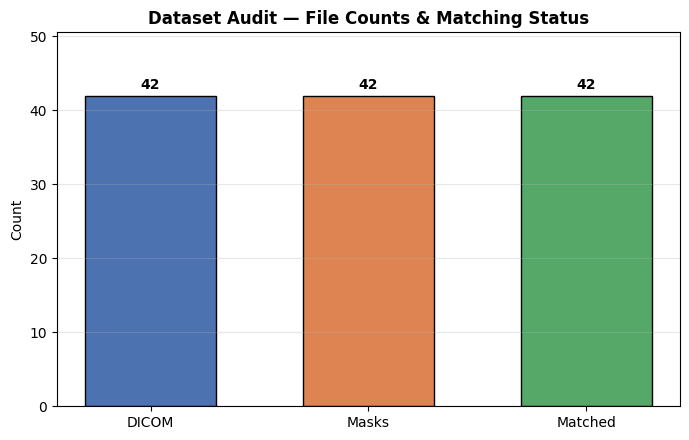

✅ Stage 0 complete.


In [30]:
# --- Visualization: data audit bar chart ---
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["DICOM", "Masks", "Matched"]
vals   = [n_dcm, n_mask, n_pair]
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(labels, vals, color=colors, edgecolor="black", width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + max(vals)*0.01 + 0.1,
            str(v), ha="center", va="bottom", fontweight="bold")
ax.set_title("Dataset Audit — File Counts & Matching Status", fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(vals)*1.18 + 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()
print("✅ Stage 0 complete.")

## Stage 1 — DICOM Preprocessing, Windowing & Dataset

Apply a spine bone window (C=400 / W=1800), Min-Max normalize to [0,1], match masks, and
build an Albumentations augmentation pipeline.

In [31]:
import pydicom
import cv2
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

def load_dicom_raw(path):
    """Return (raw_pixels_float, windowed_uint?) -> here we return float HU-ish array.
    Applies RescaleSlope/Intercept if present so 'raw' is in attenuation units."""
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept
    # MONOCHROME1 -> invert so higher value = denser/brighter, consistent with MONOCHROME2
    if str(getattr(ds, "PhotometricInterpretation", "MONOCHROME2")) == "MONOCHROME1":
        arr = arr.max() - arr
    return arr  # "raw" attenuation array, used later for BMD

def apply_window(arr):
    """Spine bone windowing + Min-Max normalize to [0,1]."""
    lo = np.percentile(arr, 1)
    hi = np.percentile(arr, 99)
    
    out = np.clip(arr, lo, hi)
    out = (out - lo) / (hi - lo + 1e-6)
    return out.astype(np.float32)  # [0,1]

# Quick sanity check on one file
if len(pairs) > 0:
    _raw = load_dicom_raw(pairs[0][0])
    _win = apply_window(_raw)
    print(f"Raw range : [{_raw.min():.1f}, {_raw.max():.1f}]  shape={_raw.shape}")
    print(f"Win range : [{_win.min():.3f}, {_win.max():.3f}]")

Raw range : [0.0, 16664.0]  shape=(256, 256)
Win range : [0.000, 1.000]


In [ ]:
import random
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

class L4Dataset(Dataset):
    """
    A single responsibility interface that strictly handles data loading and tensor conversion.
    """
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        dp, mp = self.pairs[i]
        
        # 1. Load DICOM raw array and apply windowing to get [0,1] image.
        raw = load_dicom_raw(dp)
        img = apply_window(raw)  # [0, 1] HxW
        
        # Mask loading with OpenCV in grayscale mode (HxW), then binarize to {0,1}
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m.shape[:2] != img.shape[:2]:
            m = cv2.resize(m, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        
        mask = (m > 0).astype(np.float32)
        
        # 3. Replicate single-channel image to 3 channels for pretrained encoders (HxWx3)
        img3 = np.repeat(img[..., None], 3, axis=2)
        
        # 4. Apply augmentation if provided, else fallback to basic tensor conversion
        if self.transform:
            augmented = self.transform(image=img3, mask=mask)
            x = augmented["image"].float()                  # 3xHxW conversion by ToTensorV2
            y = augmented["mask"].unsqueeze(0).float()      # 1xHxW dimension expansion for binary mask
        else:
            # Fallback (safety net)
            x = torch.from_numpy(img3.transpose(2, 0, 1)).float()
            y = torch.from_numpy(mask).unsqueeze(0).float()
            
        return x, y


class L4DataModule:
    """
    Data splitting, batch provider (Loader) assembly, and orchestration-focused modern module
    """
    def __init__(self, pairs, cfg, train_transform=None, val_transform=None):
        self.pairs = pairs
        self.cfg = cfg
        self.train_transform = train_transform
        self.val_transform = val_transform
        
        self.train_ds = None
        self.val_ds = None

    def setup(self):
        """
        Replace index manipulation with safe copying of original data to preserve splits
        """
        shuffled_pairs = self.pairs.copy()
        random.seed(42)
        random.shuffle(shuffled_pairs)
        
        total_len = len(shuffled_pairs)
        n_val = max(1, int(total_len * self.cfg.VAL_SPLIT)) if total_len else 0
        
        # split by slicing instead of index manipulation to preserve original data integrity
        val_pairs = shuffled_pairs[:n_val]
        train_pairs = shuffled_pairs[n_val:]
                
        # Create train val dataset 
        self.train_ds = L4Dataset(train_pairs, transform=self.train_transform)
        self.val_ds = L4Dataset(val_pairs, transform=self.val_transform)
        
        print(f"📊 [DataModule] Setup complete | Train samples: {len(self.train_ds)} | Val samples: {len(self.val_ds)}")

    def get_train_loader(self):
        return DataLoader(
            self.train_ds, 
            batch_size=self.cfg.BATCH, 
            shuffle=True,
            num_workers=self.cfg.NUM_WORKERS, 
            drop_last=False,
            pin_memory=True if self.cfg.NUM_WORKERS > 0 else False  # GPU transfer optimization acceleration 
        )

    def get_val_loader(self):
        return DataLoader(
            self.val_ds, 
            batch_size=self.cfg.BATCH, 
            shuffle=False,
            num_workers=self.cfg.NUM_WORKERS,
            pin_memory=True if self.cfg.NUM_WORKERS > 0 else False
        )

In [ ]:
# 1. Compose declaration
train_tf = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=12, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
    ToTensorV2(),
])

# 2. Initialize the DataModule with pairs, config, and transforms, then call setup to prepare datasets
data_module = L4DataModule(
    pairs=pairs, 
    cfg=cfg, 
    train_transform=train_tf, 
    val_transform=val_tf
)
data_module.setup()

# 3. Get loaders (these can be passed directly to the Trainer's fit method)
train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

📊 [DataModule] Setup complete | Train samples: 34 | Val samples: 8


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class DataVisualizer:
    """
    Utility class dedicated to validating the data pipeline and visualizing results
    """
    @staticmethod
    def show_pipeline_triplets(dataset, n_samples=3, stage_title="Stage 1 — Data Verification"):
        """
        Visualize a few samples from the dataset in a 3-column format: [DICOM | Mask | Overlay].
        """
        n = min(n_samples, len(dataset))
        if n == 0:
            print("⚠️ There are no samples to visualize in the dataset.")
            return

        # Create a grid of subplots with 3 columns (DICOM, Mask, Overlay) and n rows (samples)
        fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n), tight_layout=True)
        
        # Ensure axes is always 2D for consistent indexing, even if n=1 (single sample)
        if n == 1: 
            axes = axes[None, :]

        for r in range(n):
            # 1. Extract tensors from dataset and convert to NumPy (ensuring CPU transfer)
            x, y = dataset[r]
            img = x[0].cpu().numpy()  # 0 channel only since it's replicated, shape HxW
            msk = y[0].cpu().numpy()  # 1xHxW -> HxW
            
            # 2. Precise channel replication and RGB overlay processing for visualization            
            # explicitly express axis addition and dimension matching format instead of np.repeat
            overlay = np.stack([img, img, img], axis=-1).copy()
            
            # Instead of a flat +0.5 boost, we can apply a more nuanced enhancement that considers the mask intensity
            overlay[..., 0] = np.clip(overlay[..., 0] + 0.5 * msk, 0.0, 1.0)
            
            # 3. Render each subplot with consistent contrast settings to maximize visibility of both image and mask details
            # Originally, the DICOM and Mask were shown with a grayscale colormap and fixed range to ensure that the details are visible regardless of the actual pixel value distribution. The overlay is shown in RGB to highlight the masked regions clearly.
            axes[r, 0].imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
            axes[r, 0].set_title(f"Sample {r+1} : DICOM (Windowed)", fontsize=10, fontweight="semibold")
            
            axes[r, 1].imshow(msk, cmap="gray", vmin=0.0, vmax=1.0)
            axes[r, 1].set_title(f"Sample {r+1} : L4 Ground Truth", fontsize=10, fontweight="semibold")
            
            axes[r, 2].imshow(overlay)
            axes[r, 2].set_title(f"Sample {r+1} : Overlay Region", fontsize=10, fontweight="semibold")

            # Loop through columns to turn off axes for a cleaner look, ensuring that the focus is on the images themselves without any distracting ticks or borders.
            for c in range(3): 
                axes[r, c].axis("off")

        # 메인 타이틀 장식
        plt.suptitle(f"{stage_title} (Augmented Samples)", fontsize=13, fontweight="bold", y=1.02)
        plt.show()

📊 [DataModule] Setup complete | Train samples: 34 | Val samples: 8


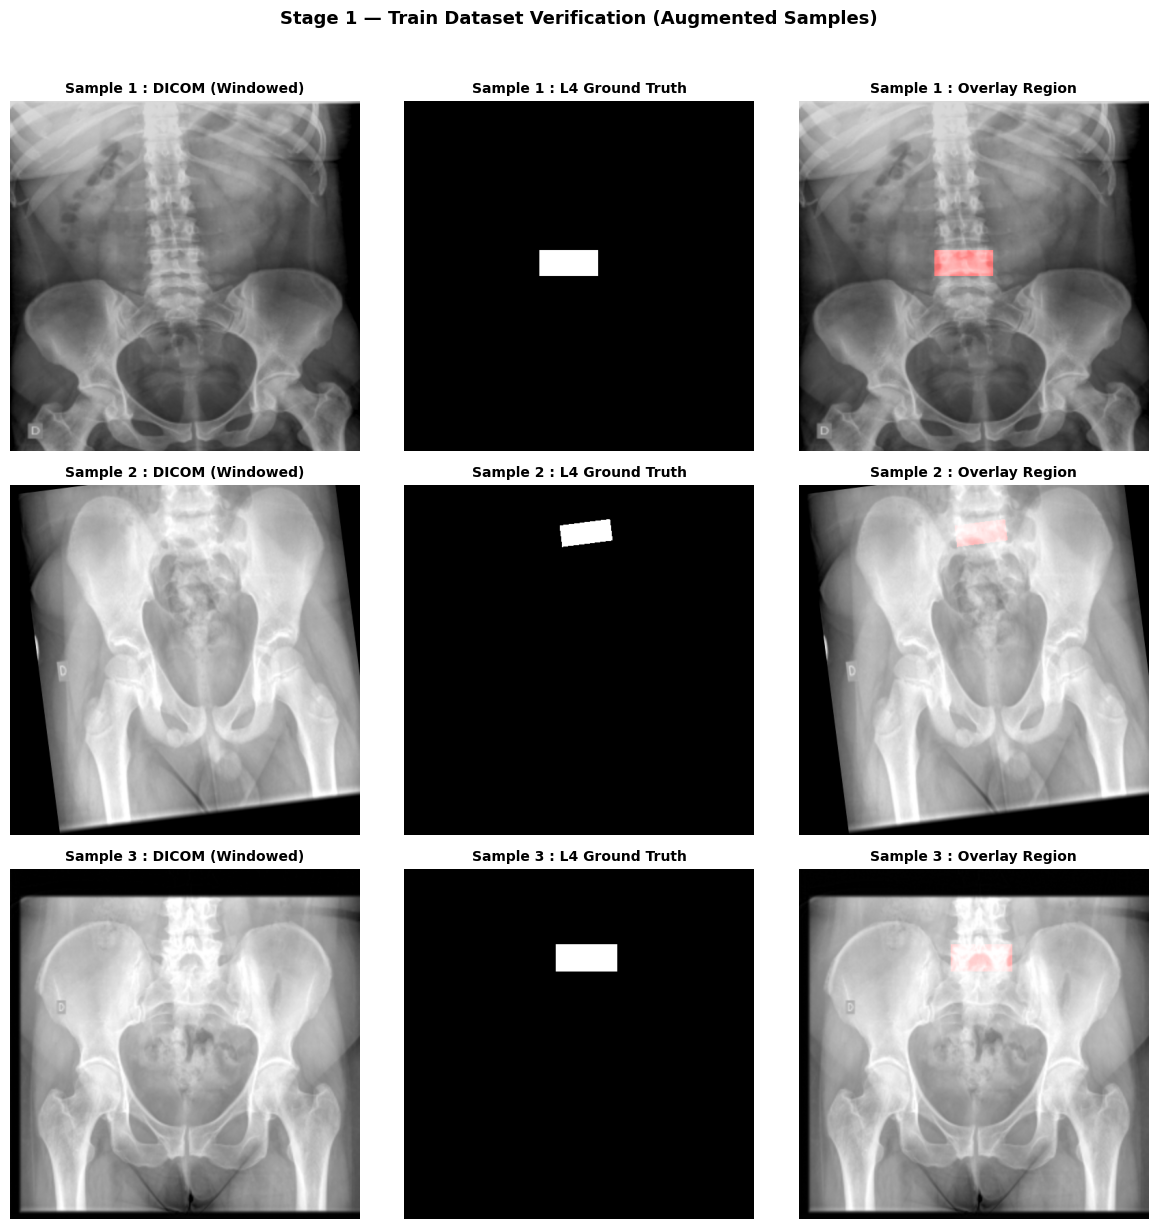

✅ Stage 1: Data pipeline verification complete.


In [ ]:
# 1. 최신 데이터 모듈 선언 및 빌드
# 1. Initialize the DataModule with pairs, config, and transforms, then call setup to prepare datasets
data_module = L4DataModule(pairs=pairs, cfg=cfg, train_transform=train_tf, val_transform=val_tf)
data_module.setup()

# 2. Call the visualization utility to display sample triplets from the training dataset for verification
# Inner dataset is accessed directly for verification purposes, which is acceptable in this controlled context since we are not modifying the dataset but only visualizing it.
DataVisualizer.show_pipeline_triplets(
    dataset=data_module.train_ds, 
    n_samples=3, 
    stage_title="Stage 1 — Train Dataset Verification"
)

print("✅ Stage 1: Data pipeline verification complete.")

## Stage 2 — UNet++ (EfficientNet-B4) Fine-Tuning for L4 Extraction

Composite loss = Dice + BCE, AdamW + CosineAnnealingLR.

In [ ]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

class MetricReporter:
    """
    Based on the training history collected during the Trainer's fit method, 
    this class provides a static method to plot the convergence curves for both loss and validation metrics. 
    It checks for the presence of training records and visualizes them in a clear, 
    publication-quality format with appropriate titles, labels, legends, and gridlines for better interpretability.
    """
    @staticmethod
    def plot_training_curves(history):
        """
        Visualize the training and validation loss curves in the upper subplot, 
        and the validation Dice and IoU metric trajectories in the lower subplot. 
        Each curve is clearly labeled with legends, and gridlines are added for better readability. 
        The method checks for the presence of training records before attempting to plot, 
        ensuring that it only runs when valid data is available.
        """
        if not history.get("train_loss"):
            print("⚠️ There is no training history to visualize.")
            return

        epochs = range(1, len(history["train_loss"]) + 1)
        
        # Two subplots: upper for loss curves, lower for metric trajectories
        fig, axes = plt.subplots(2, 1, figsize=(10, 8), tight_layout=True)
        
        # 1. Visualize Loss curves (upper subplot)
        axes[0].plot(epochs, history["train_loss"], "-o", label="Train Loss", color="#4C72B0", markersize=5)
        axes[0].plot(epochs, history["val_loss"], "-s", label="Val Loss", color="#DD8452", markersize=5)
        axes[0].set_title("Loss Convergence Curve", fontsize=11, fontweight="bold")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Loss Value")
        axes[0].legend(frameon=True)
        axes[0].grid(axis="both", alpha=0.3)

        # 2. Visualize Metric curves (lower subplot)
        axes[1].plot(epochs, history["val_dice"], "-o", label="Val Dice Score", color="#55A868", markersize=5)
        axes[1].plot(epochs, history["val_iou"], "-s", label="Val IoU (Jaccard)", color="#C44E52", markersize=5)
        axes[1].set_title("Validation Metric Trajectory", fontsize=11, fontweight="bold")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Score (0.0 ~ 1.0)")
        axes[1].set_ylim(0.0, 1.0)
        axes[1].legend(frameon=True)
        axes[1].grid(axis="both", alpha=0.3)

        plt.suptitle("Stage 2 — Performance Evaluation Overview", fontsize=13, fontweight="bold", y=1.02)
        plt.show()


class SegmentationTrainer:
    """
    UNet++ Segmentation pipeline's dedicated engine for training, validation, and checkpointing
    """
    def __init__(self, model, optimizer, scheduler, device, checkpoint_path="best_model.pth"):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.checkpoint_path = checkpoint_path
        
        # Binary segmentation tasks often benefit from a combination of Dice Loss, 
        # which focuses on overlap and is sensitive to class imbalance, and BCEWithLogitsLoss, 
        # which provides pixel-wise classification feedback. 
        # This hybrid approach can lead to more stable training and better convergence, 
        # especially in medical imaging tasks where the foreground (e.g., L4 vertebra) may occupy a small portion of the image.
        self.dice_loss = smp.losses.DiceLoss(mode="binary")
        self.bce_loss = nn.BCEWithLogitsLoss()
        
        self.history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
        self.best_dice = -1.0

    def _criterion(self, logits, target):
        return self.dice_loss(logits, target) + self.bce_loss(logits, target)

    @staticmethod
    def calculate_metrics(logits, target, thr=0.5, eps=1e-6):
        prob = torch.sigmoid(logits)
        pred = (prob > thr).float()
        
        inter = (pred * target).sum(dim=(1, 2, 3))
        psum = pred.sum(dim=(1, 2, 3))
        tsum = target.sum(dim=(1, 2, 3))
        
        union = psum + tsum
        dice = ((2 * inter + eps) / (union + eps)).mean().item()
        iou = ((inter + eps) / (union - inter + eps)).mean().item()
        return dice, iou

    def train_one_epoch(self, train_loader):
        self.model.train()
        total_loss = 0.0
        nb = 0
        
        for x, y in train_loader:
            x, y = x.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()
            logits = self.model(x)
            loss = self._criterion(logits, y)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            nb += 1
            
        return total_loss / max(nb, 1)

    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0.0
        total_dice = 0.0
        total_iou = 0.0
        nb = 0
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(self.device), y.to(self.device)
                logits = self.model(x)
                
                total_loss += self._criterion(logits, y).item()
                d, i = self.calculate_metrics(logits, y)
                total_dice += d
                total_iou += i
                nb += 1
                
        return total_loss / max(nb, 1), total_dice / max(nb, 1), total_iou / max(nb, 1)

    def fit(self, train_loader, val_loader, epochs):
        print(f"🚀 [Core Engine] Initiating Fine-Tuning Pipeline for {epochs} Epochs...")
        
        for epoch in range(1, epochs + 1):
            tr_loss = self.train_one_epoch(train_loader)
            v_loss, vd, vi = self.validate(val_loader)
            self.scheduler.step()

            self.history["train_loss"].append(tr_loss)
            self.history["val_loss"].append(v_loss)
            self.history["val_dice"].append(vd)
            self.history["val_iou"].append(vi)

            # We save the model checkpoint whenever we achieve a new best validation Dice score, 
            # which is a common practice in segmentation tasks to ensure that we retain the best-performing model weights based on the most relevant metric for the task.
            if vd > self.best_dice:
                self.best_dice = vd
                torch.save(self.model.state_dict(), self.checkpoint_path)
                
            current_lr = self.scheduler.get_last_lr()[0]
            print(f"[{epoch:02d}/{epochs}] train_loss={tr_loss:.4f} val_loss={v_loss:.4f} "
                  f"dice={vd:.4f} iou={vi:.4f} | lr={current_lr:.2e}")
            
        print(f"✅ [Core Engine] Pipeline Done. Best Val Dice: {self.best_dice:.4f} -> Weights: {self.checkpoint_path}")
        return self.history

🚀 [Core Engine] Initiating Fine-Tuning Pipeline for 30 Epochs...
[01/30] train_loss=1.6646 val_loss=1.8540 dice=0.0234 iou=0.0118 | lr=9.97e-05
[02/30] train_loss=1.5617 val_loss=1.7113 dice=0.0238 iou=0.0120 | lr=9.89e-05
[03/30] train_loss=1.4905 val_loss=1.6056 dice=0.0390 iou=0.0199 | lr=9.76e-05
[04/30] train_loss=1.4308 val_loss=1.5056 dice=0.0973 iou=0.0517 | lr=9.57e-05
[05/30] train_loss=1.3794 val_loss=1.4128 dice=0.2720 iou=0.1616 | lr=9.33e-05
[06/30] train_loss=1.3284 val_loss=1.3560 dice=0.4671 iou=0.3082 | lr=9.05e-05
[07/30] train_loss=1.2883 val_loss=1.3364 dice=0.4280 iou=0.2768 | lr=8.72e-05
[08/30] train_loss=1.2517 val_loss=1.3017 dice=0.4009 iou=0.2563 | lr=8.35e-05
[09/30] train_loss=1.2162 val_loss=1.2774 dice=0.3627 iou=0.2476 | lr=7.94e-05
[10/30] train_loss=1.2045 val_loss=1.2648 dice=0.4032 iou=0.2909 | lr=7.50e-05
[11/30] train_loss=1.1764 val_loss=1.2252 dice=0.4940 iou=0.3510 | lr=7.03e-05
[12/30] train_loss=1.1569 val_loss=1.2131 dice=0.5025 iou=0.3583 |

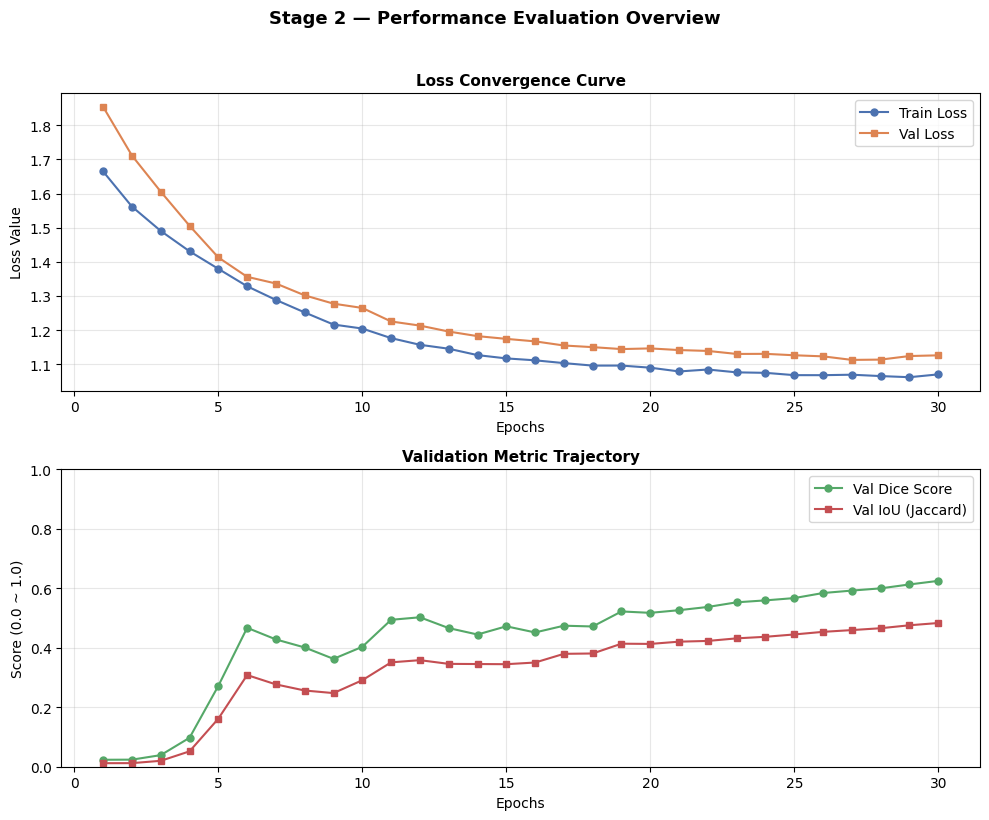

✅ Stage 2 complete.


In [ ]:
# 1. Model Architecture Instantiation (EfficientNet-B4 Backbone)
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
)

# 2. optimizer injection with AdamW and Cosine Annealing LR scheduler, 
# which are commonly used for fine-tuning segmentation models to achieve better convergence and generalization.
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)

# 3. Initialize the Trainer engine with the model, optimizer, scheduler, device, and checkpoint path for automated saving of best weights based on validation performance.
trainer = SegmentationTrainer(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    checkpoint_path=cfg.CKPT
)

# 4. Based on the initialized Trainer and the DataModule's train and validation loaders, 
history = trainer.fit(train_loader, val_loader, epochs=cfg.EPOCHS)

# 5. Use the dedicated MetricReporter to visualize the training curves 
MetricReporter.plot_training_curves(history)

print("✅ Stage 2 complete.")

## Stage 3 — Heuristic Proxy-BMD Scoring (Unsupervised)

No DEXA ground truth exists, so we build a **proxy** score. Raw single-image pixel means are
distorted by acquisition dose (kVp/mA), so we use a **reference-ratio**: L4 attenuation relative
to a soft-tissue reference region in the same image. This cancels much of the exposure bias.

$\text{ProxyScore} = \dfrac{\text{percentile}_{90}(\text{L4 raw})}{\text{median}(\text{reference raw}) + \epsilon}$

In [43]:
@torch.no_grad()
def predict_mask(model, img_win01, size=cfg.IMG_SIZE, thr=0.5):
    """img_win01: HxW float[0,1]. Returns binary mask at ORIGINAL size + prob map at net size."""
    H, W = img_win01.shape
    img3 = np.repeat(cv2.resize(img_win01, (size, size))[..., None], 3, 2)
    x = torch.from_numpy(img3.transpose(2,0,1)).unsqueeze(0).float().to(DEVICE)
    model.eval()
    prob = torch.sigmoid(model(x))[0,0].cpu().numpy()   # size x size
    mask_full = cv2.resize((prob > thr).astype(np.uint8), (W, H),
                           interpolation=cv2.INTER_NEAREST)
    return mask_full.astype(bool), prob

def reference_region_value(raw, mask):
    """Soft-tissue reference: median of raw pixels OUTSIDE the L4 mask within the
    central body area (excludes very dark background)."""
    body = raw > np.percentile(raw, 25)        # drop dark air/background
    ref = raw[body & (~mask)]
    return float(np.median(ref)) if ref.size else float(np.median(raw))

def proxy_bmd(raw, mask):
    """Compute proxy BMD stats from L4 region of the RAW attenuation array."""
    vals = raw[mask]
    if vals.size == 0:
        return None
    mean_v = float(np.mean(vals))
    std_v  = float(np.std(vals))
    p90    = float(np.percentile(vals, 90))
    ref    = reference_region_value(raw, mask)
    ratio  = p90 / (ref + 1e-6)                 # exposure-robust proxy
    return {"mean": mean_v, "std": std_v, "p90": p90,
            "ref": ref, "ratio": ratio, "pixels": int(vals.size), "vals": vals}

# Heuristic T-score-like banding on the ratio (TUNE on your cohort distribution!)
def classify_bmd(ratio):
    if ratio >= 1.35:   return "Normal",       "#55A868"
    elif ratio >= 1.15: return "Osteopenia",   "#DD8452"
    else:               return "Osteoporosis", "#C44E52"

print("Proxy-BMD functions ready. NOTE: ratio thresholds must be calibrated "
      "against a labelled subset before any interpretation.")

Proxy-BMD functions ready. NOTE: ratio thresholds must be calibrated against a labelled subset before any interpretation.


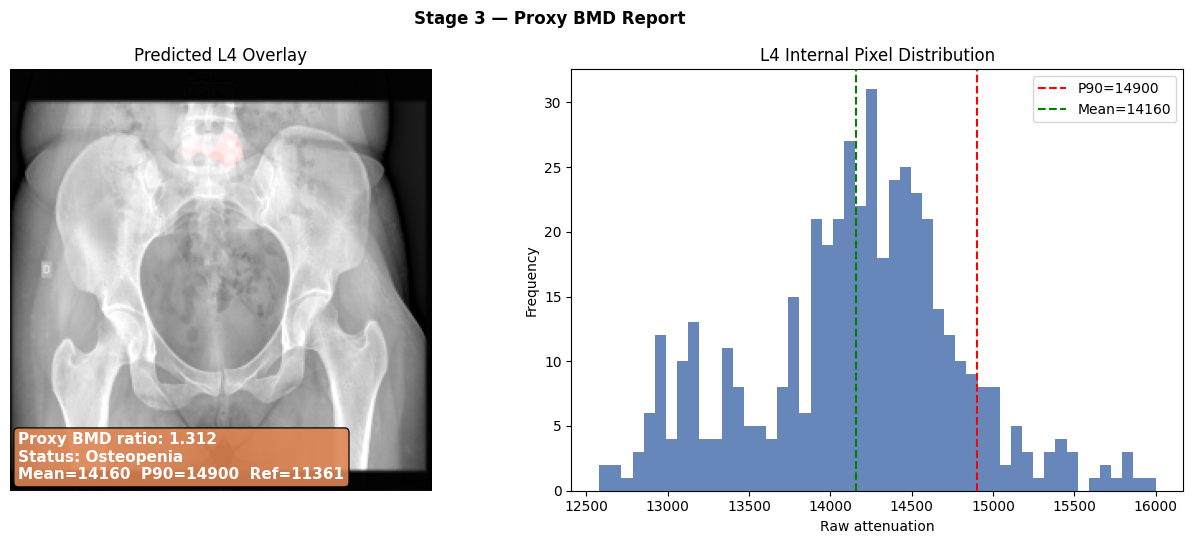

✅ Stage 3 complete.


In [44]:
# --- Visualization: BMD report on one test image ---
def bmd_report(model, pair):
    dp, _ = pair
    raw = load_dicom_raw(dp)
    win = apply_window(raw)
    mask, prob = predict_mask(model, win)
    stats = proxy_bmd(raw, mask)
    if stats is None:
        print("No L4 region predicted for this image."); return
    status, color = classify_bmd(stats["ratio"])

    over = np.repeat(win[..., None], 3, 2).copy()
    over[..., 0] = np.clip(over[..., 0] + 0.45*mask, 0, 1)

    fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
    ax[0].imshow(over); ax[0].set_title("Predicted L4 Overlay"); ax[0].axis("off")
    ax[1].hist(stats["vals"], bins=50, color="#4C72B0", alpha=0.85)
    ax[1].axvline(stats["p90"], color="red", ls="--", label=f"P90={stats['p90']:.0f}")
    ax[1].axvline(stats["mean"], color="green", ls="--", label=f"Mean={stats['mean']:.0f}")
    ax[1].set_title("L4 Internal Pixel Distribution")
    ax[1].set_xlabel("Raw attenuation"); ax[1].set_ylabel("Frequency"); ax[1].legend()

    txt = (f"Proxy BMD ratio: {stats['ratio']:.3f}\n"
           f"Status: {status}\n"
           f"Mean={stats['mean']:.0f}  P90={stats['p90']:.0f}  Ref={stats['ref']:.0f}")
    ax[0].text(0.02, 0.02, txt, transform=ax[0].transAxes, va="bottom", ha="left",
               fontsize=11, color="white", fontweight="bold",
               bbox=dict(boxstyle="round", facecolor=color, alpha=0.9))
    plt.suptitle("Stage 3 — Proxy BMD Report", fontweight="bold")
    plt.tight_layout(); plt.show()
    return stats

if len(val_pairs):
    _ = bmd_report(model, val_pairs[0])
print("✅ Stage 3 complete.")

## Stage 4 — Grad-CAM Explainability

Target the deepest encoder feature map and check the model attends to L4 morphology.

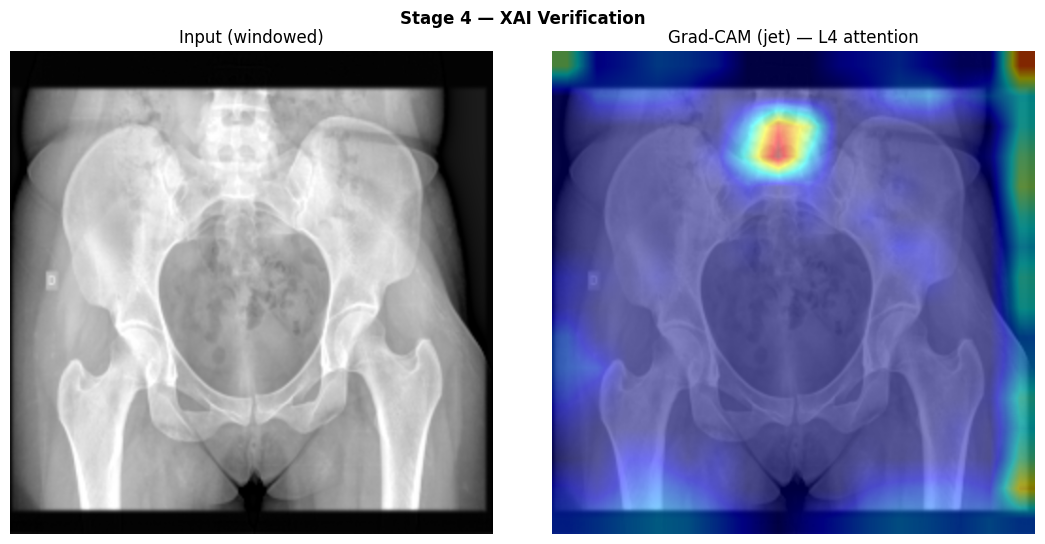

✅ Stage 4 complete.


In [45]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class SemanticSegmentationTarget:
    """Score = sum of mask-region logits for the chosen category."""
    def __init__(self, mask):
        self.mask = torch.from_numpy(mask.astype(np.float32))
    def __call__(self, model_output):
        m = self.mask.to(model_output.device)
        return (model_output[0] * m).sum()

def run_gradcam(model, pair):
    dp, _ = pair
    raw = load_dicom_raw(dp); win = apply_window(raw)
    mask, _ = predict_mask(model, win)

    img3 = np.repeat(cv2.resize(win, (cfg.IMG_SIZE, cfg.IMG_SIZE))[..., None], 3, 2)
    rgb = img3.astype(np.float32)
    x = torch.from_numpy(img3.transpose(2,0,1)).unsqueeze(0).float().to(DEVICE)

    # EfficientNet-B4 deepest block in smp encoder:
    target_layers = [model.encoder._blocks[-1]]
    mask_small = cv2.resize(mask.astype(np.uint8),
                            (cfg.IMG_SIZE, cfg.IMG_SIZE),
                            interpolation=cv2.INTER_NEAREST)
    targets = [SemanticSegmentationTarget(mask_small)]

    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale = cam(input_tensor=x, targets=targets)[0]
    vis = show_cam_on_image(rgb, grayscale, use_rgb=True, colormap=cv2.COLORMAP_JET)

    fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
    ax[0].imshow(rgb); ax[0].set_title("Input (windowed)"); ax[0].axis("off")
    ax[1].imshow(vis); ax[1].set_title("Grad-CAM (jet) — L4 attention"); ax[1].axis("off")
    plt.suptitle("Stage 4 — XAI Verification", fontweight="bold")
    plt.tight_layout(); plt.show()

if len(val_pairs):
    try:
        run_gradcam(model, val_pairs[0])
    except Exception as e:
        print(f"Grad-CAM note: {e}\nIf the target layer name differs, inspect "
              "model.encoder and pick the last conv block.")
print("✅ Stage 4 complete.")

## Stage 5 — Inference Wrapper & Streamlit Porting Guide

In [46]:
def predict_bmd_pipeline(dicom_path, model=None, ckpt=cfg.CKPT, thr=0.5):
    """Single-call wrapper: DICOM path -> preprocess -> segment -> proxy BMD -> result dict.

    Returns:
        dict with keys: overlay (HxWx3 [0,1]), histogram_values, ratio, mean,
                        std, p90, ref, status, color
    """
    if model is None:
        model = smp.UnetPlusPlus("efficientnet-b4", encoder_weights=None,
                                 in_channels=3, classes=1, activation=None).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()

    raw = load_dicom_raw(dicom_path)
    win = apply_window(raw)
    mask, prob = predict_mask(model, win, thr=thr)
    stats = proxy_bmd(raw, mask)
    if stats is None:
        return {"error": "No L4 region detected."}
    status, color = classify_bmd(stats["ratio"])

    overlay = np.repeat(win[..., None], 3, 2).copy()
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.45*mask, 0, 1)
    return {
        "overlay": overlay,
        "histogram_values": stats["vals"],
        "ratio": stats["ratio"], "mean": stats["mean"], "std": stats["std"],
        "p90": stats["p90"], "ref": stats["ref"],
        "status": status, "color": color,
    }

# Smoke test
if len(val_pairs):
    r = predict_bmd_pipeline(val_pairs[0][0], model=model)
    print({k: v for k, v in r.items() if k not in ("overlay", "histogram_values")})
print("✅ Stage 5 wrapper ready.")

{'ratio': 1.3115042688749665, 'mean': 14160.41796875, 'std': 641.4940795898438, 'p90': 14900.0, 'ref': 11361.0, 'status': 'Osteopenia', 'color': '#DD8452'}
✅ Stage 5 wrapper ready.


### Streamlit porting guide

Save the helpers (`load_dicom_raw`, `apply_window`, `predict_mask`, `proxy_bmd`,
`classify_bmd`, `predict_bmd_pipeline`) into `bmd_core.py`, then create `app.py`:

```python
import streamlit as st
import matplotlib.pyplot as plt
import numpy as np, tempfile
from bmd_core import predict_bmd_pipeline

st.set_page_config(page_title="L4 Proxy-BMD", layout="wide")
st.title("Lumbar L4 — Proxy Bone Density (research only)")
st.caption("Not a DEXA T-score. For research/visualization purposes only.")

up = st.file_uploader("Upload pelvic X-ray DICOM", type=["dcm", "dicom"])
if up:
    with tempfile.NamedTemporaryFile(delete=False, suffix=".dcm") as f:
        f.write(up.read()); path = f.name
    res = predict_bmd_pipeline(path)
    if "error" in res:
        st.error(res["error"])
    else:
        c1, c2 = st.columns(2)
        with c1:
            fig, ax = plt.subplots(); ax.imshow(res["overlay"]); ax.axis("off")
            ax.set_title("Predicted L4 Overlay"); st.pyplot(fig)
        with c2:
            fig2, ax2 = plt.subplots()
            ax2.hist(res["histogram_values"], bins=50)
            ax2.set_title("L4 Pixel Distribution"); st.pyplot(fig2)
        st.markdown(f"### Status: :{'green' if res['status']=='Normal' else 'orange'}[{res['status']}]")
        st.metric("Proxy BMD ratio", f"{res['ratio']:.3f}")
```

Run with: `streamlit run app.py`

**Calibration reminder:** before any interpretation, fit the `classify_bmd` thresholds on a
labelled subset (if/when DEXA or expert labels become available) — the current bands are
placeholders.

In [ ]:
class SegmentationPredictor:
    """
    Constructed with a focus on modularity and reusability, this class encapsulates the loading of model weights,
the preprocessing of input DICOM images, the inference process to generate binary masks, and a static
    """
    def __init__(self, model_architecture, checkpoint_path, device):
        self.device = device
        self.model = model_architecture.to(device)
        
        # Check if weight file exists, then load
        if os.path.exists(checkpoint_path):
            self.model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            print(f"🎯 [Predictor] Successfully loaded weights from: {checkpoint_path}")
        else:
            raise FileNotFoundError(f"❌ There is no weight file at: {checkpoint_path}")
            
        self.model.eval()

    def predict_single(self, dicom_path, img_size=512):
        """
        Takes a single DICOM file path and returns a NumPy array of binary masks (0 or 1).
        """

        # 1. Raw Data Loading and Preprocessing
        raw = load_dicom_raw(dicom_path)
        img_windowed = apply_window(raw)  # HxW, [0, 1] scale
        
        # 2. Resize to fit model input specifications and duplicate 3 channels
        # Control preprocessing with lightweight OpenCV instead of Albumentations during the inference phase
        img_resized = cv2.resize(img_windowed, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        img_3ch = np.stack([img_resized, img_resized, img_resized], axis=-1)  # HxWx3
        
        # 3. Tensor Transformation and Dimensional Expansion (HxWx3 -> 1x3xHxW)
        input_tensor = torch.from_numpy(img_3ch.transpose(2, 0, 1)).unsqueeze(0).float().to(self.device)
        
        # 4. Inference Model
        with torch.no_grad():
            logits = self.model(input_tensor)
            probs = torch.sigmoid(logits)                  # Convert Raw Logits to Probability Values (0~1)
            pred_mask = (probs > 0.5).float()              # Binarization based on a 0.5 threshold
            
        # 5. Convert to NumPy boat format (HxW) for visualization and post-processing
        final_mask = pred_mask.squeeze().cpu().numpy()
        return img_resized, final_mask

    @staticmethod
    def visualize_prediction(image, predicted_mask, title="Model Inference Result"):
        """
        Outputs an overlay report by comparing the predicted results with the original.
        """
        fig, axes = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
        
        # RGB Overlay Composite
        overlay = np.stack([image, image, image], axis=-1).copy()
        overlay[..., 0] = np.clip(overlay[..., 0] + 0.5 * predicted_mask, 0.0, 1.0)  # L4 Prediction Area Red Boosting
        
        axes[0].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
        axes[0].set_title("Input DICOM (Windowed)")
        
        axes[1].imshow(predicted_mask, cmap="gray", vmin=0.0, vmax=1.0)
        axes[1].set_title("Predicted L4 Mask")
        
        axes[2].imshow(overlay)
        axes[2].set_title("Predicted Overlay Region")
        
        for ax in axes:
            ax.axis("off")
            
        plt.suptitle(title, fontsize=12, fontweight="bold", y=1.05)
        plt.show()

🎯 [Predictor] Successfully loaded weights from: best_l4_unetpp.pth
🎬 추론 대상 DICOM: 1.2.826.0.1.3680043.8.498.90188614108641468056830101349132081242-c.dcm


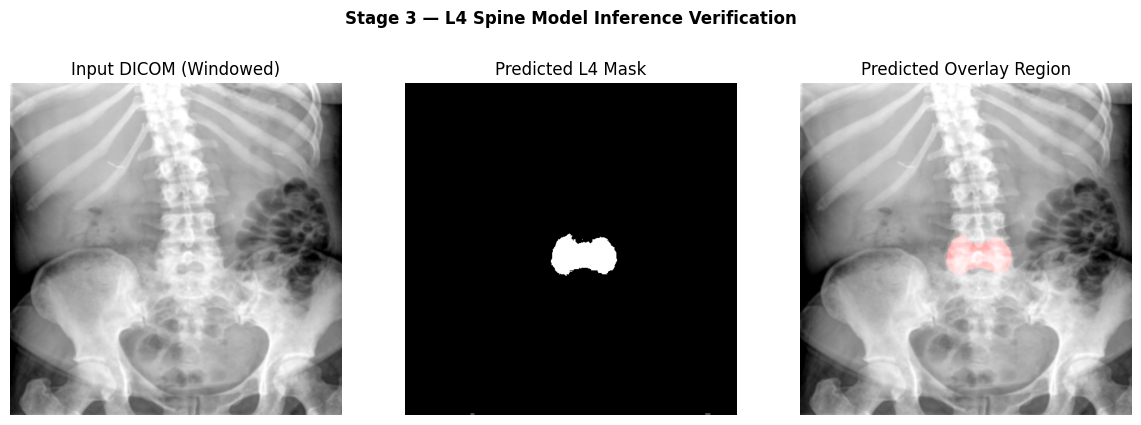

✅ Prediction flow complete.


In [ ]:
# 1. Instantiating an empty model architecture for inference

inference_model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",
    encoder_weights=None,  # During inference, only the architecture is needed, so skip ImageNet weight download
    in_channels=3,
    classes=1,
    activation=None,
)

# 2. Instantiating the predictor engine and loading weight files
predictor = SegmentationPredictor(
    model_architecture=inference_model,
    checkpoint_path=cfg.CKPT,
    device=DEVICE
)

# 3. Testing by inferring a single DICOM file from the validation dataset
test_dicom_path, test_gt_mask_path = val_pairs[1]  # Extract DICOM path from validation pair

print(f"🎬 Inference Target DICOM: {os.path.basename(test_dicom_path)}")

# 4. Predict
processed_img, pred_l4_mask = predictor.predict_single(test_dicom_path, img_size=cfg.IMG_SIZE)

# 5. Visualization of the prediction results with an overlay report
predictor.visualize_prediction(processed_img, pred_l4_mask, title="Stage 3 — L4 Spine Model Inference Verification")

print("✅ Prediction flow complete.")

In [ ]:
import pandas as pd
import seaborn as sns

class BoneDensityAnalyzer:
    """
    A class that extracts pixels inside a segmentation mask to perform Bone Mineral Density (BMD) surface marker and statistical texture analysis.
    """
    @staticmethod
    def analyze_l4_density(dicom_path, predicted_mask, img_size=512):
        """
        Calculate bone density statistics by combining the raw pixel values ​​of the original DICOM with the prediction mask.
        """
        # 1. Load original raw pixels (extract actual physical/material values ​​without Windowing applied)
        raw_arr = load_dicom_raw(dicom_path)
        raw_resized = cv2.resize(raw_arr, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        
        # 2. Extract bone pixels within the predicted mask region
        # Extract only the raw pixel values at coordinates where the mask value is 1

        bone_pixels = raw_resized[predicted_mask > 0.5]
        
        if len(bone_pixels) == 0:
            print("⚠️ [Analyzer] Bone density cannot be measured as the predicted L4 vertebral region is missing.")
            return None, None

        # 3. Clinical statistics data generation (Mean as BMD proxy, Std/Percentile as texture indicators)
        stats = {
            "Metric": [
                "L4 ROI Area (Pixels)",
                "Mean Density (BMD Proxy)",
                "Density Std (Texture Noise)",
                "Min Intensity",
                "25th Percentile",
                "Median Intensity",
                "75th Percentile",
                "Max Intensity"
            ],
            "Value": [
                len(bone_pixels),
                np.mean(bone_pixels),
                np.std(bone_pixels),
                np.min(bone_pixels),
                np.percentile(bone_pixels, 25),
                np.median(bone_pixels),
                np.percentile(bone_pixels, 75),
                np.max(bone_pixels)
            ]
        }
        df_stats = pd.DataFrame(stats)
        return df_stats, bone_pixels

    @staticmethod
    def plot_bmd_report(df_stats, bone_pixels, filename=""):
        """
        Renders a comprehensive report combining the bone density analysis metrics table and the internal pixel distribution histogram.
        """
        if df_stats is None or bone_pixels is None:
            return

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
        
        # Left tab: Organize statistical summary table output
        axes[0].axis("off")
        table_data = [[m, f"{v:,.2f}"] for m, v in zip(df_stats["Metric"], df_stats["Value"])]
        
        # --- BoneDensityAnalyzer.plot_bmd_report Modify existing internal table settings section ---
        table = axes[0].table(
            cellText=table_data,
            colLabels=["Bone Density Metric", "Statistical Value"],
            loc="center",
            cellLoc="left",
            colWidths=[0.6, 0.4]
        )
        
        table.auto_set_font_size(False)
        table.FONTSIZE = 11
        
        # for cell in table.get_celld().values():
        #     cell.set_fontsize(11)
            
        table.scale(1.0, 1.8)  # Ensuring readability with cell height
        axes[0].set_title(f"📊 L4 Vertebral Body Quantitative Report\n[{filename}]", fontsize=12, fontweight="bold", loc="left")
        # ------------------------------------------------------------------------

        # Right tab: Bone density internal pixel texture distribution (Histogram and KDE)
        sns.histplot(bone_pixels, kde=True, ax=axes[1], color="#4C72B0", bins=40, edgecolor="white", alpha=0.7)
        axes[1].axvline(np.mean(bone_pixels), color="#C44E52", linestyle="--", linewidth=2, label=f"Mean BMD: {np.mean(bone_pixels):,.1f}")
        axes[1].set_title("L4 Intra-vertebral Pixel Intensity Distribution (Texture)", fontsize=11, fontweight="bold")
        axes[1].set_xlabel("Raw Pixel Value (HU / Raw Signal Intensity)")
        axes[1].set_ylabel("Pixel Count")
        axes[1].legend(frameon=True)
        axes[1].grid(axis="both", alpha=0.3)

        plt.suptitle("Stage 4 — Bone Mineral Density (BMD) & Texture Quantification", fontsize=14, fontweight="bold", y=1.05)
        plt.show()

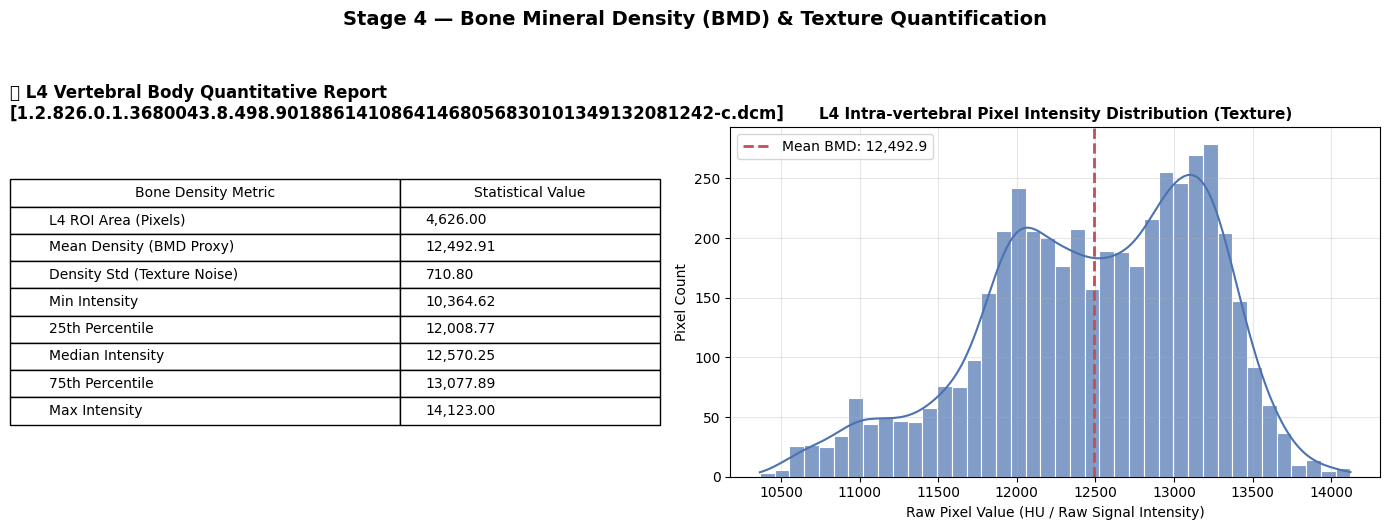

✅ Stage 4: Bone density quantitative analysis complete.


In [ ]:
# 1. Perform mask inference using the advanced predictor engine from Step 3
processed_img, pred_l4_mask = predictor.predict_single(test_dicom_path, img_size=cfg.IMG_SIZE)

# 2. Perform bone density analysis (mapping raw pixels with predicted mask)
fn_short = os.path.basename(test_dicom_path)
df_bmd_report, bone_raw_pixels = BoneDensityAnalyzer.analyze_l4_density(
    dicom_path=test_dicom_path,
    predicted_mask=pred_l4_mask,
    img_size=cfg.IMG_SIZE
)

# 3. Plot the comprehensive quantitative analysis report
BoneDensityAnalyzer.plot_bmd_report(df_bmd_report, bone_raw_pixels, filename=fn_short)

print("✅ Stage 4: Bone density quantitative analysis complete.")

==========================================================================================================

In [58]:
!pip install datasets pillow

   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 555.1/555.1 kB 19.5 MB/s  0:00:00

   ------- --------------------------------  2/11 [multidict]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   -------------- -------------------------  4/11 [dill]
   ------------------ ---------------------  5/11 [aiohappyeyeballs]
   --------------------- ------------------  6/11 [yarl]
   ------------------------- --------------  7/11 [multiprocess]
   ------------------------- --------------  7/11 [multiprocess]
   ------------------------- --------------  7/11 [multiprocess]
   --------

In [59]:
# 허깅페이스 데이터셋 라이브러리 설치 (필요시 주석 해제 후 실행)
# !pip install datasets pillow

import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 기존 노트북의 장치(DEVICE) 설정 유지
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [60]:
import segmentation_models_pytorch as smp

# 1. 모델 아키텍처 정의 (기존 노트북 설정: UNet++ / EfficientNet-B4)
# 주의: 기존 학습 시 설정한 encoder_name과 classes 수에 맞추어야 합니다.
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4", 
    encoder_weights=None, # 가중치를 새로 로드하므로 None
    in_channels=3, 
    classes=1
)

# 2. 저장된 체크포인트 파일 경로 설정
CKPT_PATH = "best_l4_unetpp.pth" 

if os.path.exists(CKPT_PATH):
    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print(f"✅ 성공적으로 모델 가중치를 로드했습니다: {CKPT_PATH}")
else:
    print(f"❌ 가중치 파일을 찾을 수 없습니다: {CKPT_PATH}. 경로를 확인해주세요.")

✅ 성공적으로 모델 가중치를 로드했습니다: best_l4_unetpp.pth


In [61]:
# 1. 허깅페이스 데이터셋 로드
print("Hugging Face 데이터셋을 다운로드 중...")
hf_dataset = load_dataset("UniqueData/spine-x-ray", split="train") # 필요에 따라 split 변경 ('train', 'validation' 등)
print(f"데이터셋 로드 완료! 총 샘플 수: {len(hf_dataset)}")

# 2. 모델 예측용 테스트 이미지 전처리 함수 정의
IMG_SIZE = 512 # 기존 훈련 크기 유지

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])

def preprocess_hf_image(pil_img):
    """
    허깅페이스에서 가져온 PIL 이미지를 모델 입력 포맷(3, 512, 512)으로 변환합니다.
    """
    # 흑백(Grayscale)인 경우 3채널 RGB로 변경
    img_np = np.array(pil_img.convert("RGB"))
    
    # [0, 255] -> [0.0, 1.0] Min-Max 정규화
    img_np = img_np.astype(np.float32) / 255.0
    
    # Albumentations 적용 (Resize 및 Tensor 변환)
    augmented = test_transform(image=img_np)
    img_tensor = augmented["image"].to(DEVICE).unsqueeze(0) # Batch 차원 추가 (1, 3, 512, 512)
    
    return img_tensor, img_np

Hugging Face 데이터셋을 다운로드 중...


README.md:   0%|          | 0.00/3.14k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/70 [00:00<?, ?it/s]

files/disability/3.jpg:   0%|          | 0.00/401k [00:00<?, ?B/s]

files/disability/1.jpg:   0%|          | 0.00/247k [00:00<?, ?B/s]

...

files/vertebral_compression_fracture/7.j(…):   0%|          | 0.00/329k [00:00<?, ?B/s]

files/vertebral_compression_fracture/9.j(…):   0%|          | 0.00/303k [00:00<?, ?B/s]

files/vertebral_compression_fracture/8.j(…):   0%|          | 0.00/448k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/69 [00:00<?, ? examples/s]

데이터셋 로드 완료! 총 샘플 수: 69


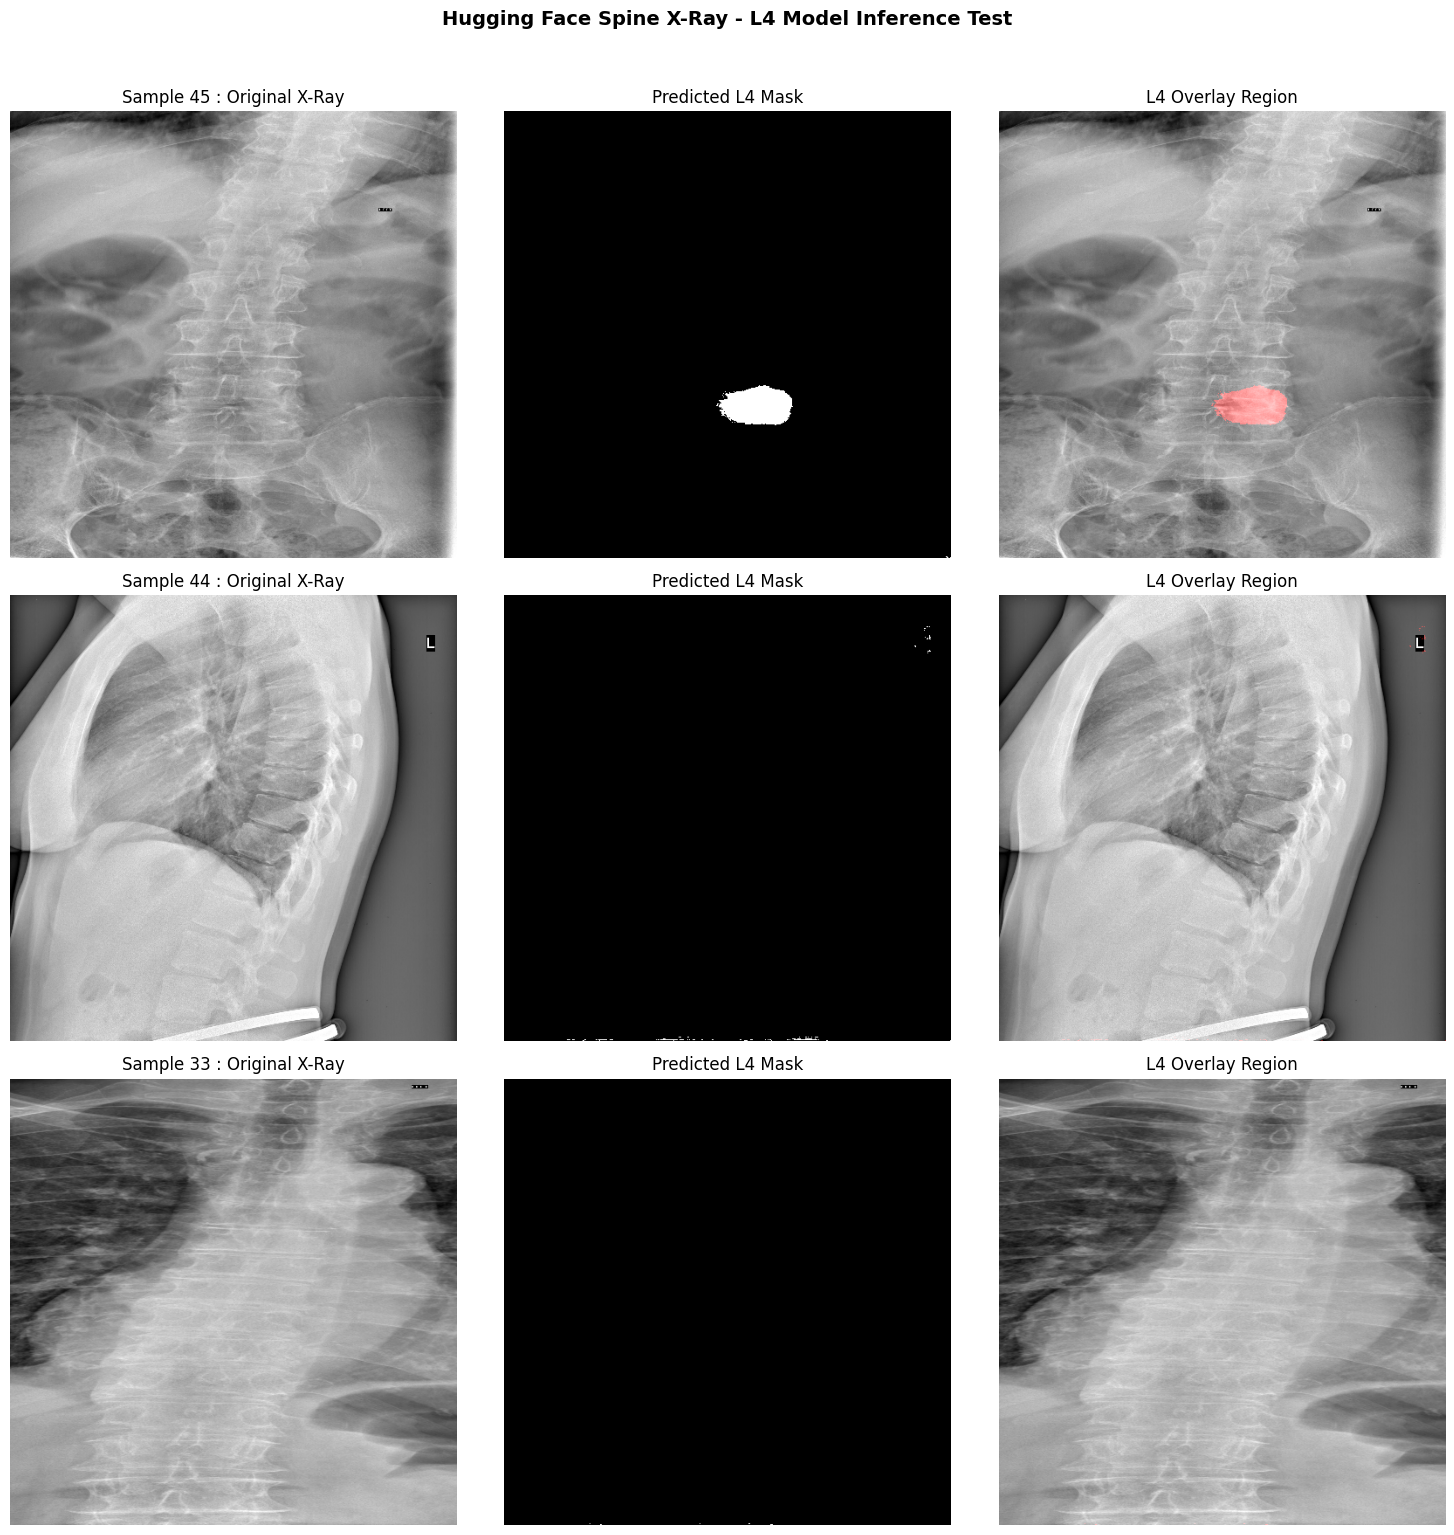

In [62]:
import random

def predict_and_visualize_hf(dataset, num_samples=3):
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        
        # 데이터셋의 구조에 맞춰 필드명 확인 필요 (보통 'image'가 원본 데이터)
        if 'image' in sample:
            pil_img = sample['image']
        else:
            # 필드명이 다를 경우 첫 번째 필드의 값을 가져옴
            first_key = list(sample.keys())[0]
            pil_img = sample[first_key]
            
        # 1. 이미지 전처리
        img_tensor, original_resized = preprocess_hf_image(pil_img)
        
        # 2. 모델 추론
        with torch.no_grad():
            output = model(img_tensor)
            pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
            pred_binary = (pred_mask > 0.5).astype(np.float32) # 임계값 0.5 기준 이진화
            
        # 3. 원본 이미지 크기에 맞게 예측 마스크 복원용 Resize 원본 저장
        # (시각화를 위해 albumentations에서 resize된 이미지 사용)
        vis_img = cv2.resize(np.array(pil_img.convert("RGB")), (IMG_SIZE, IMG_SIZE))
        vis_img = vis_img / 255.0 # 시각화를 위해 0~1 정규화
        
        # Red 채널에 마스크 효과 오버레이
        overlay = vis_img.copy()
        overlay[..., 0] = np.clip(overlay[..., 0] + 0.4 * pred_binary, 0.0, 1.0) 
        
        # 4. 시각화 플롯팅
        axes[i, 0].imshow(vis_img)
        axes[i, 0].set_title(f"Sample {idx} : Original X-Ray")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(pred_binary, cmap="gray", vmin=0.0, vmax=1.0)
        axes[i, 1].set_title("Predicted L4 Mask")
        axes[i, 1].axis("off")
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("L4 Overlay Region")
        axes[i, 2].axis("off")
        
    plt.suptitle("Hugging Face Spine X-Ray - L4 Model Inference Test", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# 테스트 실행 (3개 샘플 확인)
predict_and_visualize_hf(hf_dataset, num_samples=3)